# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# cargar archivo
df = pd.read_csv('landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  str    
 1   date            40000 non-null  str    
 2   landing         40000 non-null  str    
 3   region          40000 non-null  str    
 4   dispositivo     40000 non-null  str    
 5   traffic_source  40000 non-null  str    
 6   user_type       40000 non-null  str    
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), str(7)
memory usage: 2.7 MB


In [5]:
# verificando duplicidad
df.duplicated().sum()

np.int64(0)

In [6]:
columnas = df.columns.tolist()


for col in columnas:
    print(col)
    print(df[col].unique())


user_id
<StringArray>
['26f3052e-8500-44ea-8fff-06de65258abb',
 '92378c09-4bbf-40c7-945e-82b84f392d22',
 'a4397360-40e5-45d6-a7ff-dcb4da2c9a1f',
 '7ca3a26f-1e6c-44aa-9b09-b8cb01112956',
 '8dc9593b-5b9c-479d-848b-a99493920419',
 '1b72e41d-e797-40b6-afb8-c2d79bee7552',
 '71897b47-3f4c-40ee-9e26-f458674755a3',
 'c00efddd-5cbb-4b7d-a1f3-1fa76866cff0',
 'f9ee7358-321d-448e-8788-90f64d22c8f9',
 'be5e7d86-884e-467f-9cf2-ece406b9eebf',
 ...
 '10c3de12-bc65-4bb1-a3fc-bb0ad2375732',
 'ea69866b-eaae-4f94-a3b1-ee3f50f41af5',
 '214377b8-84d8-4c8e-8ae7-c9817be46701',
 '964319d3-a328-474d-9506-8ce2329224e7',
 '4a0c1285-5233-4fed-b350-fd227a3501f5',
 'ea6e2b9f-f7f3-49aa-beb6-c7beec1fc154',
 '47b071d9-e39a-4d57-bb96-d01cc9e6ca0c',
 '02fbb5df-c7a7-4286-a8bc-97bd741fa2d7',
 '299ad979-d990-458f-81a8-b9fd21a023b0',
 'fabb98e7-0f74-4baf-9a32-ac8e09936787']
Length: 40000, dtype: str
date
<StringArray>
['2026-01-01', '2026-01-23', '2026-01-22', '2026-01-16', '2026-01-27',
 '2026-01-28', '2026-01-02', '2026-01

✍️ **Comentario**:

- No se encuentran valores nulos en ninguna columna
  
- La columna `date` es de tipo *object*, requiere conversion a *datetime*

- El dataset no tiene registros duplicados

- Las columnas no tienen valores fuera de contexto (centinels)

- Las columnas tienen sus valores en formato correcto (mayúsculas, minusculas)

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [7]:
df["user_id"].nunique()

40000

In [8]:
df["user_id"].duplicated().sum()

np.int64(0)

 **Variable `date`**  
Explorar rango de fechas

In [9]:
# Se realiza conversión de tipo de dato object a datetime
df['date'] = pd.to_datetime(df['date'])
# Resumen estadístico
df["date"].describe()

count                  40000
mean     2026-01-14 11:41:06
min      2026-01-01 00:00:00
25%      2026-01-07 00:00:00
50%      2026-01-14 00:00:00
75%      2026-01-21 00:00:00
max      2026-01-28 00:00:00
Name: date, dtype: object

In [10]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [11]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [12]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted']==1].describe()

,date,converted,gasto
count,5706,5706.0,5706.000000
mean,2026-01-14 11:11:47.886435,1.0,65.373668
min,2026-01-01 00:00:00,1.0,12.120000
25%,2026-01-07 00:00:00,1.0,42.950000
50%,2026-01-15 00:00:00,1.0,59.860000
75%,2026-01-21 00:00:00,1.0,80.370000
max,2026-01-28 00:00:00,1.0,303.680000
std,NaN,0.0,30.896545


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [13]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")

cat_cols= ['landing','region','dispositivo','traffic_source','user_type']

for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("-------"*5)


Conteo de categorías:
landing
<StringArray>
['A', 'B']
Length: 2, dtype: str
-----------------------------------
region
<StringArray>
['Norte', 'Occidente', 'Centro', 'Sur', 'Oriente']
Length: 5, dtype: str
-----------------------------------
dispositivo
<StringArray>
['Mobile', 'Desktop']
Length: 2, dtype: str
-----------------------------------
traffic_source
<StringArray>
['Email', 'Organic', 'Ads', 'Referral']
Length: 4, dtype: str
-----------------------------------
user_type
<StringArray>
['Recurrente', 'Nuevo']
Length: 2, dtype: str
-----------------------------------


In [14]:
for col in cat_cols:
    print(col)
    print(df[col].value_counts(normalize=True).round(3)*100)
    print("-------"*5)

landing
landing
B    50.0
A    50.0
Name: proportion, dtype: float64
-----------------------------------
region
region
Norte        27.9
Centro       24.0
Sur          20.1
Occidente    16.0
Oriente      12.0
Name: proportion, dtype: float64
-----------------------------------
dispositivo
dispositivo
Mobile     62.1
Desktop    37.9
Name: proportion, dtype: float64
-----------------------------------
traffic_source
traffic_source
Organic     45.0
Ads         29.8
Email       15.3
Referral     9.9
Name: proportion, dtype: float64
-----------------------------------
user_type
user_type
Nuevo         65.1
Recurrente    34.9
Name: proportion, dtype: float64
-----------------------------------


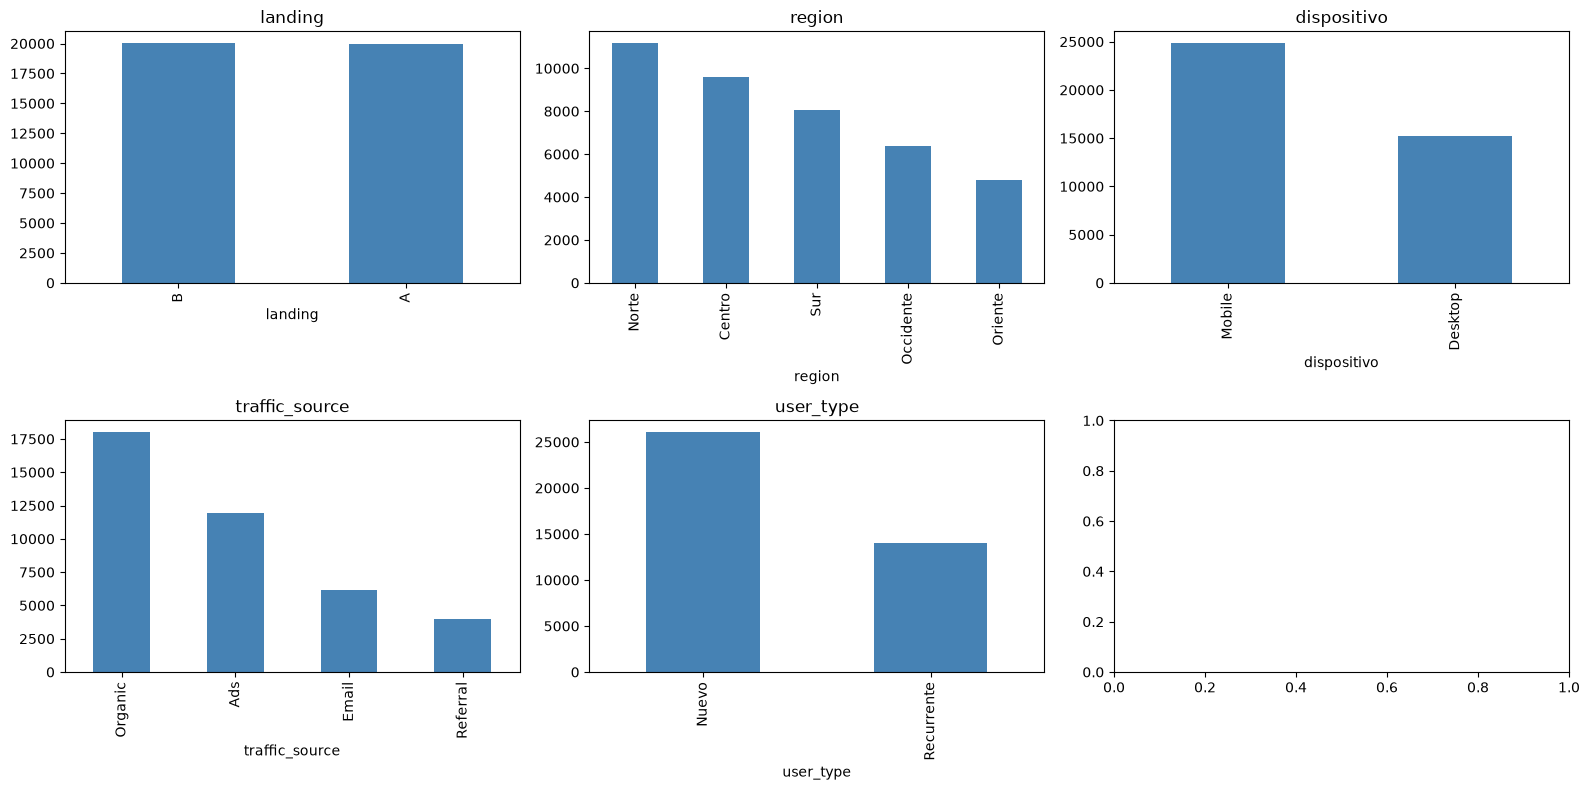

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves
- Landing: Sin errores
- Region: Sin errores ni datos fuera de contexto, valores escritos correctamente. Region norte con mayor numero de conversiones, mientras que region Oriente con menor numero de conversiones
- Dispositivo, sin errores
- Traffic_Source: Sin errores, con mayor numero de conversiones del tipo *Organic*, y con el menor numero de conversiones del tipo *Referreal*
- User_Type: Sin errores, mayor numero de conversiones de clientes nuevos, mientras que los clientes recurrentes representan la mitad de los clientes nuevos.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [16]:
# Gasto por versión


gasto_A = df[(df['landing']=='A') & (df['converted']==1)]['gasto']
gasto_B = df[(df['landing']=='B') & (df['converted']==1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)


(2512, 3194)

In [17]:
print("Promedio de gasto (A):", gasto_A.mean())
print("Promedio de gasto (B):", gasto_B.mean())
print()
print("Diferencia gasto_B - gasto_A:", gasto_B.mean() - gasto_A.mean())

Promedio de gasto (A): 61.0865724522293
Promedio de gasto (B): 68.74536005009392

Diferencia gasto_B - gasto_A: 7.658787597864624


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El promedio de gasto de los clientes de las páginas A y B son el mismo o muy similares
- **Hipótesis alternativa (H₁):** El promedio de gasto de los clientes de la página B es mayor que el promedio de gasto en la página A, por lo que se recomienda implementar <mark>**B**</mark>

In [18]:
#definicion de alpha

alpha = 0.05

# se agrega Test de Levene para verificación de varianzas entre gasto_A y gasto_B

levene_stat, levene_p = stats.levene(gasto_A, gasto_B)
print(f"Levene: estadistico = {levene_stat}, p_value={levene_p}")

# definición de equal_var segun el resultado de levene
equal_var = levene_p > alpha
print(f"Varianzas iguales? {equal_var} -> equal_var = {equal_var}")

# Aplicar prueba t-student
t_stat, p_value = ttest_ind(gasto_B, gasto_A, equal_var = equal_var)


# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Levene: estadistico = 29.17646453202917, p_value=6.875301988006788e-08
Varianzas iguales? False -> equal_var = False
Estadístico : 9.48101092267275
Valor p: 3.627602231521537e-21


In [19]:
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia estadística de una diferencia")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia estadística suficiente de una diferencia")

Rechazamos la hipótesis nula: hay evidencia estadística de una diferencia


### 📝 Conclusión e interpretación




**Decisión:**  
Con un *p_value* de 1.06e-20 (menor a 0.05) y un *t_test* de -9.3, **Se recomienda implementar página B como reemplazo de la página A** dado que hay evidencia estadística suficiente de una diferencia de **7.65** en el gasto promedio de los usuarios realizando la resta de gasto promedio de B menos gasto promedio de A.

**Interpretación de negocio:**  
La pagina B genera mas valor económico, por lo que se recomienda migrar el tráfico de la página A a la página B y aprovechar el aprendizaje de este experimento.

***Limitaciones***
- El resultado se basa en una muestra de los usuarios del *01 de Enero del 2026* al *28 de Enero del 2026*
- Se analizaron usuarios de todas las regiones, tipos de dispositivos y fuente de tráfico, por lo que la conclusion podria cambiar si se realiza el analisis con una segmentación diferente.
- Los usuarios solo compran en una de las dos paginas, no hay usuarios que hayan comprado en las dos páginas.
- No se verificó si los datos siguen una distribución normal






---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión entre las páginas A y B es el mismo o muy similar.
- **Hipótesis alternativa (H₁):** La tasa de conversión de la pagina B es mayor que la tasa de conversión de la página A.

In [20]:
# Número de usuarios convertidos por página
num_usuarios_A = df[(df['landing']=='A') & (df['converted']==1)]['user_id'].count()
num_usuarios_B = df[(df['landing']=='B') & (df['converted']==1)]['user_id'].count()

num_total_usuarios_A = df[df['landing']=='A']['user_id'].count()
num_total_usuarios_B = df[df['landing']=='B']['user_id'].count()

# Total de usuarios por página


print("Usuarios convertidos por página:\n")

print("Pagina A: ", num_usuarios_A)
print("Pagina B: ", num_usuarios_B)

print("\nTotal de usuarios por página:\n")

print("Pagina A: ", num_total_usuarios_A)
print("Pagina B: ", num_total_usuarios_B)


Usuarios convertidos por página:

Pagina A:  2512
Pagina B:  3194

Total de usuarios por página:

Pagina A:  19982
Pagina B:  20018


In [21]:
exitos = [num_usuarios_A, num_usuarios_B]
observaciones = [num_total_usuarios_A, num_total_usuarios_B]

In [22]:
# Aplicar prueba
#importando libreria faltante
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(exitos, observaciones)


# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

#interpretando resultados


if p_value < alpha:
    print("Se rechaza hipotesis nula, hay evidencia de una diferencia")
else:
    print("No se rechaza hipótesis nula, hay evidencia estadistica de una diferencia")


Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22
Se rechaza hipotesis nula, hay evidencia de una diferencia


In [23]:
# porcentaje de conversion

porcentaje_A = (num_usuarios_A / num_total_usuarios_A) * 100
print(porcentaje_A)

porcentaje_B = (num_usuarios_B / num_total_usuarios_B) * 100
print(porcentaje_B)



12.571314182764487
15.955639924068338


### 📝 Conclusión e interpretación



**Decisión:**  
Teniando un *p_value* igual a *3.76e-22* concluimos que la hipótesis nula se rechaza, esto quiere decir que la pagina B genera mas conversiones que la pagina A. (B = 15.9% > A = 12.5%)

**Interpretación de negocio:**  
La pagina B tiene mayor posibilidad de conversion por lo que se recomienda mandar todo el trafico de la página A a la página B.

***Limitaciones***
- El resultado se basa en una muestra de los usuarios del *01 de Enero del 2026* al *28 de Enero del 2026*
- Se analizaron usuarios de todas las regiones, tipos de dispositivos y fuente de tráfico, por lo que la conclusión podria cambiar si se realiza el analisis con una segmentación diferente.
- Cada usuario solo estuvo expuesto a una de las dos paginas
- El valor p_value no puede identificar de que fuente de tráfico provienen los usuarios
- Dado que se cuentan con miles de exitos y fracasos en cada grupo, la z-test es apropiada para este ejercicio. 

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La conversión de los usuarios es independiente de la fuente de trafico
- **Hipótesis alternativa (H₁):** La conversión de los usuarios depende de la fuente de trafico, es decir, al menos una fuente de trafico tiene una tasa de conversion distinta a las demás.

In [24]:
#tabla de contingencia normalizada

pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


In [25]:

# tabla de contingencia para prueba Chi2

tabla = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla)


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [26]:
# Aplicar prueba
from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"\nchi2: {chi2_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"grados de libertad: {dof}")



chi2: 8.6621
p-value: 0.034138
grados de libertad: 3


In [27]:

if p_value < alpha:
    print("Se rechaza hipotesis nula, la conversión depende de la fuente de tráfico")
else:
    print("No se rechaza hipótesis nula, no hay evidencia de dependencia")



Se rechaza hipotesis nula, la conversión depende de la fuente de tráfico


### 📝 Conclusión e interpretación


**Decisión:**  
Se rechaza hipótesis nula, existe diferencia estadísticamente significativa en la tasa de conversión segun la fuente de tráfico con un *chi2 = 8.66* y un *p_value = 0.03* (menor a umbral de 0.05)

**Interpretación de negocio:**  
Email y Ads muestran tasas de conversión mas altas (aproximadamente del 15%), mientras que Organic y Referreal son ligeramente menores (aproximadamente del 14%). La diferencia es notablemente menor al efecto observado entre versiones A/B, por lo que el canal de adquisición tiene un efecto secundario frente al diseño de las páginas.



## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La conversión de los usuarios es independiente de su tipo
- **Hipótesis alternativa (H₁):** La conversión de los usuarios depende del tipo de usuario

In [28]:

#tabla de contingencia normalizada

pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100


converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


In [29]:
# tabla de contingencia para prueba Chi2

tabla = pd.crosstab(df['user_type'], df['converted'])
print(tabla)


converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [30]:
# Aplicar prueba

chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"\nchi2: {chi2_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"grados de libertad: {dof}")

if p_value < alpha:
    print("Se rechaza hipotesis nula, la conversión depende de la fuente de tráfico")
else:
    print("No se rechaza hipótesis nula, no hay evidencia de dependencia")


chi2: 0.5135
p-value: 0.473634
grados de libertad: 1
No se rechaza hipótesis nula, no hay evidencia de dependencia


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza hipótesis nula, no hay evidencia de dependencia, es decir, el tipo de usuario no influye en la conversión. Las tasas de conversión son prácticamente las mismas (Usuario Nuevo: 14.35% vs Usuario Recurrente: 14.09%)

**Interpretación de negocio:**  
No se encontro evidencia estadísticamente significativa de que el tipo de usuario (nuevo vs recurrente) influya en la tasa de conversión. El efecto de conversión de la pagina B es independiente de si el usuario es nuevo o recurrente. 

<div class="alert alert-block alert-success">
<b>Comentario de la revisora [Iteración 1]</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
La evaluación del tipo de usuario vs conversión está correctamente trabajada. Usas una tabla de contingencia y aplicas chi-cuadrado, que es la prueba adecuada para analizar la relación entre dos variables categóricas.
</div>


## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

Text(0, 0.5, 'Conversiones')

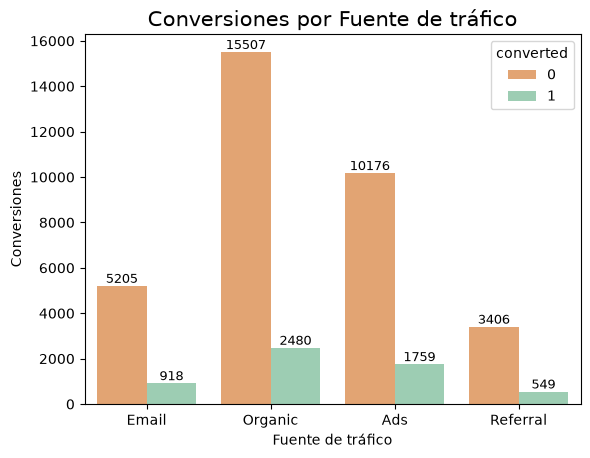

In [31]:

tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla_normalizada = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100


ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette = ["#F4A261", "#95D5B2"])
#numeros en cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9)
        
plt.title("Conversiones por Fuente de tráfico", fontsize=15)
plt.xlabel("Fuente de tráfico")
plt.ylabel("Conversiones")



✍️ **Comentario**: Este gráfico muestra la distribución de conversión segmentada por fuente de tráfico en el periodo de *01 de Enero del 2026 al 28 de Enero del 2026*. 

- El gráfico muestra que `Organic` es la fuente de trafico con mayor número de usuarios convertidos (2480). Muy por encima de los demás canales

- `Ads` es la segunda fuente de trafico con mayor numero de usuarios convertidos (1759)

- `Email` tiene menor volumen que *Organic* y *Ads* (918 usuarios convertidos)

- `Referral` es la fuente de tráfico con menor número de usuarios convertidos (549)

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


Text(0.5, 1.0, 'Tasa de conversión por fuente de tráfico')

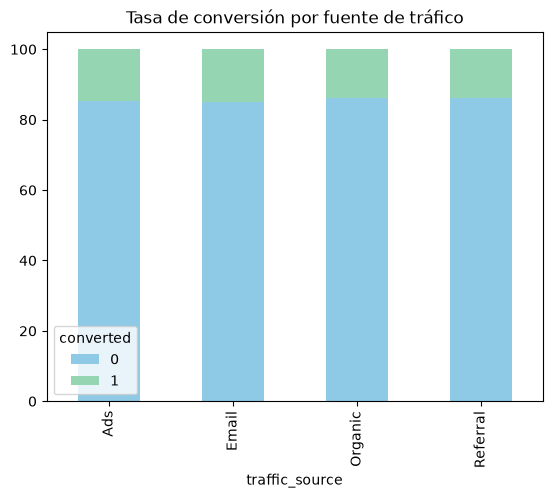

In [32]:
print(tabla_normalizada)

tabla_normalizada.plot(kind='bar', stacked=True, color=["#8ecae6", "#95d5b2"])
        
plt.title("Tasa de conversión por fuente de tráfico")

✍️ **Comentario**: En este gráfico se representa la tasa de conversión por fuente de tráfico

Puede observarse que todas las fuentes de tráfico tienen una tasa de conversion muy similar. Sin embargo, tomando en cuenta los valores **absolutos** del gráfico `Conversiones por fuente de tráfico` podemos decir que el canal con mas eficiencia es el canal de `Email`, a pesar de que tiene menor volumen de usuarios.

### Relación entre el tipo de usuario y la conversión

Text(0, 0.5, 'Conversiones')

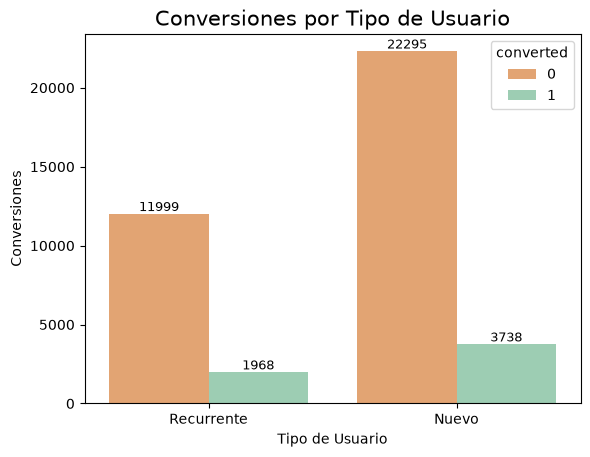

In [33]:
tabla = pd.crosstab(df['user_type'], df['converted'])
tabla_normalizada = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100


ax = sns.countplot(data=df, x='user_type', hue='converted', palette = ["#F4A261", "#95D5B2"])
#numeros en cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9)
        
plt.title("Conversiones por Tipo de Usuario", fontsize=15)
plt.xlabel("Tipo de Usuario")
plt.ylabel("Conversiones")


✍️ **Comentario**: Este gráfico representa la distribución de conversión segmentada por tipo de usuario

- Puede observarse que los usuarios nuevos tienden a convertir levemente mas que los recurrentes.

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


Text(0.5, 1.0, 'Tasa de conversión por tipo de Usuario')

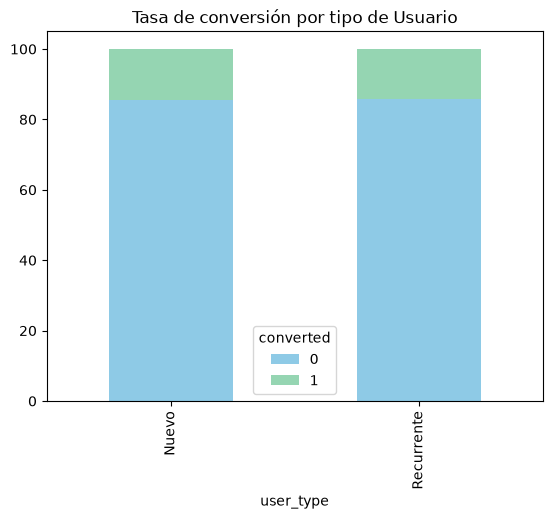

In [34]:
print(tabla_normalizada)

tabla_normalizada.plot(kind='bar', stacked=True, color=["#8ecae6", "#95d5b2"])
        
plt.title("Tasa de conversión por tipo de Usuario")

✍️ **Comentario**: Este gráfico muestra la tasa de conversión segmentado por tipo de usuario (Nuevo, Recurrente)

- Los usuarios **nuevos** muestran un mayor porcentaje de conversión comparado con los usuarios **recurrentes** con una diferencia de **0.27%**.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---


### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**

**Gasto promedio por usuario que convirtió:**

- El numero de usuarios convertidos por la página A es de *2512* con un promedio de gasto de *61.08*
- El numero de usuarios convertidos por la pagina B es de *3194* con un promedio de gasto de *68.74*
- **Interpretación:** La pagina **B** esta generando mas conversiones lo que influye en mayor valor económico, ya que el promedio de gasto en esta misma sea mayor al de la página **A**

<br>

**Tasa de conversión:**

- La página A tiene un *12.57%* de tasa de conversión
- La página B tiene un *15.95%* de tasa de conversión
- **Interpretación:** La pagina **B** esta generando mejores resultados de conversión con una diferencia de *3.38%* en comparación a la página **A**

Con el gasto promedio se estableció como Hipotesis Nula (H$0$) que las paginas A y B generaban el mismo numero de conversiónes y gasto promedio.

Al realizar la prueba `t-student` obtuvimos un *p_value* de **1.06e-20** , así también, se realizó la prueba `z-test` con la que obtuvimos un *p_value* de **3.76e-22**, ambos con *p_value* menor al umbral predefinido de **0.05** por lo que en ambas pruebas se rechazó la hipotesis nula, favoreciendo a la pagina **B** como la de mejores resultados (mayor número de conversiones, mayor gasto promedio)

#### 📊 **Segmentación por fuente de tráfico**

- La fuente `Organic` fue de la que se generaron mayor numero conversiones de usuarios (2480), seguido de `Ads` que genero 1759. En tercer lugar, de la fuente `Email` se generaron 918 conversiones y en último lugar la fuente `Referral` con 549 conversiones.
  
- Desde la perspectiva de tasa de conversión, obtuvimos mayor eficiencia de la fuente `Email` y `Ads`, con porcentajes de conversion muy similares ( ~15%)
  
- **Interpretación:** Las fuentes `Email` y `Ads` son las que tienen mayor eficiencia de conversión, por lo que el canal de adquisición tiene un efecto secundario frente al diseño de las páginas.
  

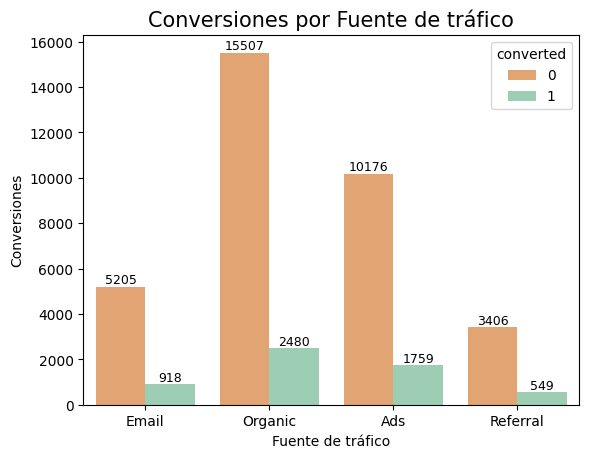

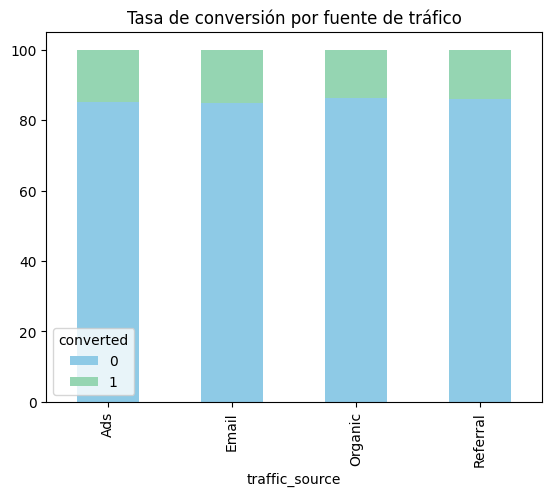

#### 📊 **Segmentación por tipo de usuario**

- Los usuarios recurrentes convertidos fueron **1968**
- Los usuarios nuevos convertidos fueron **3738**
- **Interpretación:** Se observó que los usuarios nuevos tienden a convertir significativamente mas que los recurrentes en números absolutos, sin embargo, en términos de tasa de conversión segmentado por tipo de usuario no hay una diferencia significativa (Recurrente = 14.09%, Nuevo = 14.35%, diferencia de 0.27%), por lo que el tipo de usuario impacta en la eficiencia de conversión.

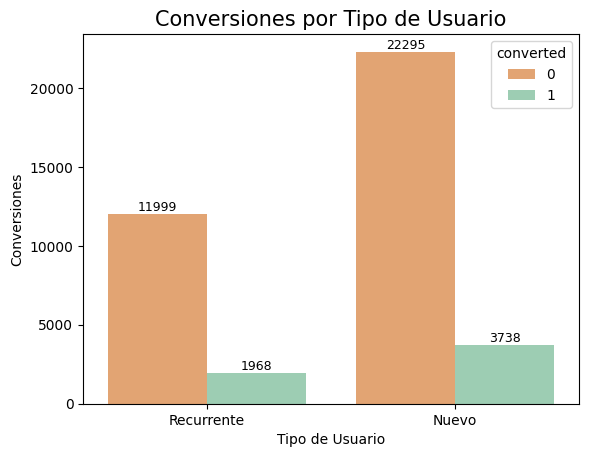

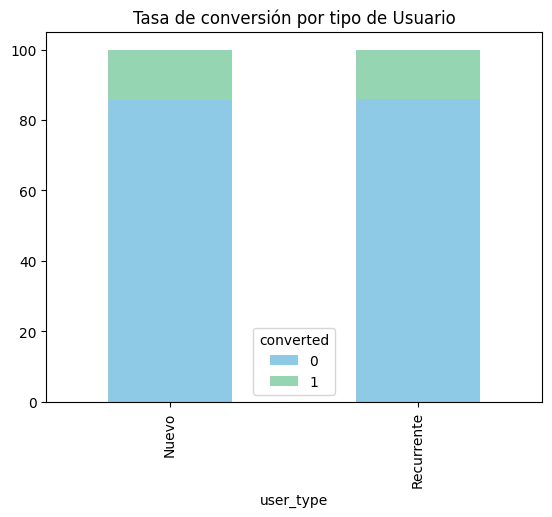

#### 💡 **Recomendaciones de negocio:**

- Con base a las pruebas estadísticas realizadas (t-student, z-test) encontramos evidencia de que la página **B** tiene mayor posibilidad de conversión por lo que se recomienda mandar todo el tráfico de la página **A** a la página **B**
- Priorizar la inversion en `Email` y `Ads` sobre *Organic* y *Referral* cuando el objetivo sea maximizar la tasa de conversión por usuario
- No segmentar estrategia por tipo de usuario dado que usuarios nuevos y recurrentes tienen tasa de conversión muy similar, no hace falta personalizar el diseño de la página según este criterio.
- Investigar por que B funciona mejor, para replicar los aprendizages en futuras paginas de venta.

#### ⛔ **Limitantes:**

- Se hizo el analisis sobre una base de datos con periodo de *01 de Enero del 2026* al *28 de Enero del 2026*.
  
- Los usuarios solo compraron en una sola página. No existen usuarios que hayan comprado en la página A y página B.
  
- Se analizaron datos de usuarios de todas las regiones y tipos de dispositivos, por lo que los resultados pueden variar si se realiza el análisis con una segmentación diferente.
